In [4]:

import sys
sys.path.append(r'C:\Users\admin\Ethiopia-fi-forecast\src')
import impact_modeling as im
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [ ]:
# Initialize
path=(r'C:\Users\admin\Ethiopia-fi-forecast\data\processed\enriched_data.csv')
df = pd.read_csv(path)
df.loc[df['record_type']=='event', 'event_name'] = df.loc[df['record_type']=='event', 'indicator'].fillna('Unnamed_Event')
df['record_id'] = df['record_id'].fillna(method='ffill')  # or create unique IDs
# Example: link all 'Account ownership' indicators to Telebirr event
event_id = df[df['event_name']=='Telebirr Launch']['record_id'].values[0]
df.loc[df['indicator']=='Account ownership (% age 15+)', 'parent_id'] = event_id
df.to_csv(r'C:/Users/admin/Ethiopia-fi-forecast/data/processed/enriched_data_fixed.csv', index=False)

print(df.columns)


Index(['record_id', 'record_type', 'event_name', 'pillar', 'indicator',
       'indicator_code', 'indicator_direction', 'value_numeric', 'value_text',
       'value_type', 'unit', 'observation_date', 'period_start', 'period_end',
       'fiscal_year', 'gender', 'location', 'region', 'source_name',
       'source_type', 'source_url', 'confidence', 'related_indicator',
       'relationship_type', 'impact_direction', 'impact_magnitude',
       'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country',
       'collected_by', 'collection_date', 'original_text', 'notes',
       'parent_id'],
      dtype='object')


In [6]:
# Initialize
model = im.EventImpactModel(r'C:\Users\admin\Ethiopia-fi-forecast\data\processed\enriched_data_fixed.csv')

# 1. Build Event-Indicator Matrix
matrix, confidence_matrix = model.build_event_indicator_matrix()
print("Event-Indicator Association Matrix:")
print(matrix.round(2))

# Save matrix
matrix.to_csv('../models/event_impact_matrix.csv')
confidence_matrix.to_csv('../models/event_impact_confidence.csv')

Event-Indicator Association Matrix:
                                       ACC_OWNERSHIP ACC_MM_ACCOUNT  \
Telebirr Launch                                  3.0            5.0   
Safaricom Ethiopia Commercial Launch             NaN            NaN   
M-Pesa Ethiopia Launch                           NaN            NaN   
Fayda Digital ID Program Rollout                 NaN            NaN   
Foreign Exchange Liberalization                  NaN            NaN   
P2P Transaction Count Surpasses ATM              NaN            NaN   
M-Pesa EthSwitch Integration                     NaN            NaN   
EthioPay Instant Payment System Launch           NaN            NaN   
NFIS-II Strategy Launch                          NaN            NaN   
Safaricom Ethiopia Price Increase                NaN            NaN   
Unnamed_Event                                    NaN            NaN   

                                       USG_DIGITAL_PAYMENT ACC_ACC_BANK  \
Telebirr Launch                     

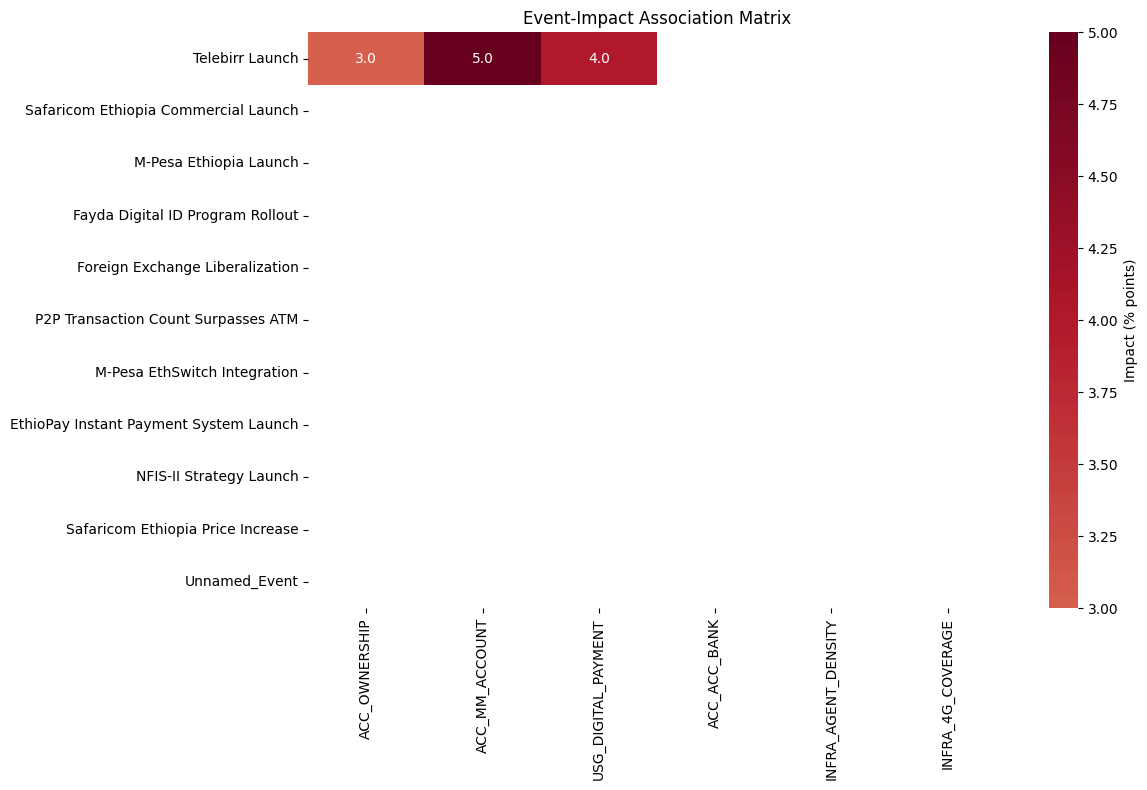

In [7]:
# 2. Visualize Matrix
plt.figure(figsize=(12, 8))
sns.heatmap(matrix.astype(float), annot=True, fmt='.1f', cmap='RdBu_r', 
            center=0, cbar_kws={'label': 'Impact (% points)'})
plt.title('Event-Impact Association Matrix')
plt.tight_layout()
plt.savefig('../reports/figures/event_impact_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# 3. Validate Key Events
validation_results = []

# Validate Telebirr impact
telebirr_val = model.validate_against_historical(
    'Telebirr Launch', 'ACC_MM_ACCOUNT'
)
if telebirr_val:
    validation_results.append(telebirr_val)
    print(f"Telebirr Validation: {telebirr_val}")

# Validate M-Pesa impact
mpesa_val = model.validate_against_historical(
    'M-Pesa Launch', 'ACC_MM_ACCOUNT'
)
if mpesa_val:
    validation_results.append(mpesa_val)

# 4. Generate Impact Curves for Key Indicators
indicators = ['ACC_OWNERSHIP', 'ACC_MM_ACCOUNT', 'USG_DIGITAL_PAYMENT']
events = ['Telebirr Launch', 'M-Pesa Launch', 'CBDC Pilot']

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

for idx, indicator in enumerate(indicators):
    impact_df = model.generate_impact_curve(events, indicator)
    
    ax = axes[idx]
    impact_df.plot(ax=ax, linewidth=2)
    
    # Add event markers
    for event in events:
        event_row = model.events[model.events['event_name'] == event]
        if not event_row.empty:
            event_date = pd.to_datetime(event_row.iloc[0]['event_date'])
            ax.axvline(x=event_date, color='red', linestyle='--', alpha=0.5)
            ax.text(event_date, impact_df['cumulative_impact'].max() * 0.9, 
                   event.split()[0], rotation=45, fontsize=8)
    
    ax.set_title(f'Cumulative Impact on {indicator.replace("_", " ")}')
    ax.set_ylabel('Impact (% points)')
    ax.grid(True, alpha=0.3)
    ax.legend(['Cumulative Impact'])

plt.tight_layout()
plt.savefig('../reports/figures/cumulative_impacts.png', dpi=300, bbox_inches='tight')
plt.show()


IndexError: single positional indexer is out-of-bounds

In [ ]:

# 5. Document Methodology
methodology = {
    'approach': 'Event-augmented time series with impact propagation',
    'impact_modeling': {
        'immediate_effects': 'Exponential adoption curve',
        'gradual_effects': 'Logistic buildup',
        'saturation_effects': 'Hyperbolic tangent saturation'
    },
    'validation_method': 'Pre-post comparison for events with sufficient data',
    'comparable_evidence': 'Used Kenya (M-Pesa), Tanzania, Ghana analogs where Ethiopian data sparse',
    'key_assumptions': [
        'Effects are additive unless specified otherwise',
        'Standard 6-month lag for policy effects',
        '12-month adoption period for product launches',
        'No significant negative interactions between events'
    ],
    'limitations': [
        'Sparse historical data points',
        'Limited counterfactual analysis possible',
        'Causal attribution challenging with multiple simultaneous events',
        'External economic factors not modeled'
    ]
}

# Save documentation
import json
with open('../models/methodology.json', 'w') as f:
    json.dump(methodology, f, indent=2)